In [3]:
##%%
import torch
import torch.nn as nn
import numpy as np
import time
import matplotlib.pyplot as plt
from matplotlib import cm
from collections import OrderedDict
from mpl_toolkits.mplot3d import Axes3D

# Set random seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
##%%
################################################################################
# Hyperparameters / Problem Setup (3D)
################################################################################
Lx = 1    # Spatial domain: x in [0, Lx]
Ly = 1     # Spatial domain: y in [0, Ly]
Lz = 1    # Spatial domain: z in [0, Lz]
T = 0.5      # Temporal domain: t in [0, T]
c = 0.5      # Wave speed

# PINN / EMMPDE Params
n_collocation = 5000 # Base number of collocation points
n_boundary    = 1500  # Number of points for boundary conditions
n_initial     = 1000  # Number of points for initial conditions
hidden_layers = 6     # Number of hidden layers
neurons       = 60    # Neurons per hidden layer
learning_rate = 1e-3  # Learning rate for optimizer
##%%
class DNN(torch.nn.Module):
    def __init__(self, layers):
        super(DNN, self).__init__()
        self.depth = len(layers) - 1
        self.activation = torch.nn.Tanh

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i + 1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)
        self.layers = torch.nn.Sequential(layerDict)

    def forward(self, x):
        out = self.layers(x)
        return out

class PINN(nn.Module):
    def __init__(self, layers, activation=nn.Tanh()):
        super(PINN, self).__init__()
        self.linears = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))

        self.activation = activation

        for m in self.linears:
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        for i in range(len(self.linears) - 1):
            x = self.activation(self.linears[i](x))

        x = self.linears[-1](x)
        return x
##%%
class sampling_MMPDE_3D():
    def __init__(self, X_f, u_fun, layers, lb, ub, nu, AdamIter, LBFGSIter):
        self.lb = torch.tensor(lb).float().to(device)
        self.ub = torch.tensor(ub).float().to(device)

        # X_f assumed to be [N, 4] -> t, x, y, z
        self.t_f = torch.tensor(X_f[:, 0:1], requires_grad=True).float().to(device)
        self.x_f = torch.tensor(X_f[:, 1:2], requires_grad=True).float().to(device)
        self.y_f = torch.tensor(X_f[:, 2:3], requires_grad=True).float().to(device)
        self.z_f = torch.tensor(X_f[:, 3:4], requires_grad=True).float().to(device)
        self.fun = u_fun

        self.layers = layers
        self.nu = nu
        self.dnn = DNN(layers).to(device)

        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-8)
        self.AdamIter = AdamIter
        self.optimizer_LBFGS = torch.optim.LBFGS(self.dnn.parameters(), lr=0.5, max_iter=LBFGSIter)

        self.optimizer = None
        self.loss = None
        self.iter = 0
        self.start_time = None

    def detach(self, data):
        return data.detach().cpu().numpy()

    def monitor(self, t, x, y, z):
        t.requires_grad_(True)
        x.requires_grad_(True)
        y.requires_grad_(True)
        z.requires_grad_(True)

        inputs = torch.cat([t, x, y, z], dim=1)
        uv = self.fun(inputs)
        u = uv[:, [0]]
        v = uv[:, [1]]

        u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), retain_graph=True, create_graph=True, allow_unused=True)[0]
        u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u), retain_graph=True, create_graph=True, allow_unused=True)[0]
        u_z = torch.autograd.grad(u, z, grad_outputs=torch.ones_like(u), retain_graph=True, create_graph=True, allow_unused=True)[0]
        u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), retain_graph=True, create_graph=True, allow_unused=True)[0]
        v_t = torch.autograd.grad(v, t, grad_outputs=torch.ones_like(v), retain_graph=True, create_graph=True, allow_unused=True)[0]

        if u_x is None: u_x = torch.zeros_like(u)
        if u_y is None: u_y = torch.zeros_like(u)
        if u_z is None: u_z = torch.zeros_like(u)
        if u_t is None: u_t = torch.zeros_like(u)
        if v_t is None: v_t = torch.zeros_like(v)


        # Monitor function: sqrt(1 + |grad u|^2 + alpha * v_t^2)
        w = 0.5 * (c**2 * (1 + u_x**2 + u_y**2 + u_z**2) + 0.1 * u_t ** 2)
        return w

    def net_sample(self, t, x, y, z):
        inputs = torch.cat([t, x, y, z], dim=1)
        xyz_new = self.dnn(inputs)

        x_new = xyz_new[:, [0]]
        y_new = xyz_new[:, [1]]
        z_new = xyz_new[:, [2]]

        # Enforce boundary preservation
        gx0 = x - self.lb[1]
        gx1 = x - self.ub[1]
        gy0 = y - self.lb[2]
        gy1 = y - self.ub[2]
        gz0 = z - self.lb[3]
        gz1 = z - self.ub[3]

        x_new = gx0 * gx1 * x_new + x
        y_new = gy0 * gy1 * y_new + y
        z_new = gz0 * gz1 * z_new + z

        return x_new, y_new, z_new

    def net_f(self, t, x, y, z):
        # Calculate coordinate mapping
        x_new, y_new, z_new = self.net_sample(t, x, y, z)

        # Gradients of the mapping w.r.t computational coordinates
        def get_grads(output, input_var):
             return torch.autograd.grad(output, input_var, grad_outputs=torch.ones_like(output), retain_graph=True, create_graph=True)[0]

        x_new_t = get_grads(x_new, t)
        y_new_t = get_grads(y_new, t)
        z_new_t = get_grads(z_new, t)

        x_new_x = get_grads(x_new, x)
        x_new_y = get_grads(x_new, y)
        x_new_z = get_grads(x_new, z)

        y_new_x = get_grads(y_new, x)
        y_new_y = get_grads(y_new, y)
        y_new_z = get_grads(y_new, z)

        z_new_x = get_grads(z_new, x)
        z_new_y = get_grads(z_new, y)
        z_new_z = get_grads(z_new, z)

        # Second derivatives
        x_new_xx = get_grads(x_new_x, x)
        x_new_yy = get_grads(x_new_y, y)
        x_new_zz = get_grads(x_new_z, z)

        y_new_xx = get_grads(y_new_x, x)
        y_new_yy = get_grads(y_new_y, y)
        y_new_zz = get_grads(y_new_z, z)

        z_new_xx = get_grads(z_new_x, x)
        z_new_yy = get_grads(z_new_y, y)
        z_new_zz = get_grads(z_new_z, z)

        # Monitor function and its gradients
        G = self.monitor(t, x, y, z)
        G_x = get_grads(G, x)
        G_y = get_grads(G, y)
        G_z = get_grads(G, z)

        # MMPDE Equations (Moving Mesh PDE in 3D)
        # Equation: x_new_t * nu * G^2 * |grad x_new|^2 = div(G * grad x_new)
        # div(G * grad x_new) = G_x * x_new_x + G_y * x_new_y + G_z * x_new_z + G * (Laplacian x_new)
        # Note: We assume cross terms in Laplacian are usually negligible or use diagonal approx if following 2D logic

        lap_x = x_new_xx + x_new_yy + x_new_zz
        lap_y = y_new_xx + y_new_yy + y_new_zz
        lap_z = z_new_xx + z_new_yy + z_new_zz

        grad_sq_x = x_new_x**2 + x_new_y**2 + x_new_z**2
        grad_sq_y = y_new_x**2 + y_new_y**2 + y_new_z**2
        grad_sq_z = z_new_x**2 + z_new_y**2 + z_new_z**2

        J = (x_new_x * (y_new_y * z_new_z - z_new_y * y_new_z)
             - y_new_x * (x_new_y * z_new_z - z_new_y * x_new_z)
             - z_new_x * (x_new_y * y_new_z - y_new_y * x_new_z) )

        a1 = y_new_y * z_new_z - z_new_y * y_new_z
        a2 = z_new_y * x_new_z - x_new_y * z_new_z
        a3 = x_new_y * y_new_z - y_new_y * x_new_z
        #a = (a1,a2,a3)

        b1 = y_new_z * z_new_x - z_new_z * y_new_x
        b2 = z_new_z * x_new_x - x_new_z * z_new_x
        b3 = x_new_z * y_new_x - y_new_z * x_new_x
        #b = (b1, b2, b3)

        c1 = y_new_x * z_new_y - z_new_x * y_new_y
        c2 = z_new_x * x_new_y - x_new_x * z_new_y
        c3 = x_new_x * y_new_y - y_new_x * x_new_y
        #c = (c1, c2, c3)

        aa = (a1 * a1 +  a2 * a2 + a3 * a3) / (G * J)
        ab = (a1 * b1 +  a2 * b2 + a3 * b3) / (G * J)
        ac = (a1 * c1 +  a2 * c2 + a3 * c3) / (G * J)
        bc = (c1 * b1 +  c2 * b2 + c3 * b3) / (G * J)
        bb = (b1 * b1 +  b2 * b2 + b3 * b3) / (G * J)
        cc = (c1 * c1 +  c2 * c2 + c3 * c3) / (G * J)

        aa_x = get_grads(aa, x)
        ab_y = get_grads(ab, y)
        ac_z = get_grads(ac, z)

        ab_x = get_grads(ab, x)
        bb_y = get_grads(bb, y)
        bc_z = get_grads(bc, z)

        bc_y = get_grads(bc, y)
        ac_x = get_grads(ac, x)
        cc_z = get_grads(cc, z)

        phi1 = aa_x + ab_y + ac_z
        phi2 = ab_x + bb_y + bc_z
        phi3 = ac_x + bc_y + cc_z


        # For x coordinate:
        #E_x = G_x * x_new_x + G_y * x_new_y + G_z * x_new_z + G * lap_x
        #f_x = x_new_t * self.nu * (G**2) * grad_sq_x + E_x
        f_x = x_new_t * self.nu * J + x_new_x * phi1 + x_new_y * phi2 + x_new_z * phi3

        # For y coordinate:
        #E_y = G_x * y_new_x + G_y * y_new_y + G_z * y_new_z + G * lap_y
        #f_y = y_new_t * self.nu * (G**2) * grad_sq_y + E_y
        f_y = x_new_t * self.nu * J + y_new_x * phi1 + y_new_y * phi2 + z_new_z * phi3

        # For z coordinate:
        #E_z = G_x * z_new_x + G_y * z_new_y + G_z * z_new_z + G * lap_z
        #f_z = z_new_t * self.nu * (G**2) * grad_sq_z + E_z
        f_z = x_new_t * self.nu * J + z_new_x * phi1 + z_new_y * phi2 + z_new_z * phi3

        return f_x, f_y, f_z

    def loss_func(self):
        f_x, f_y, f_z = self.net_f(self.t_f, self.x_f, self.y_f, self.z_f)
        loss_f = torch.mean(f_x ** 2) + torch.mean(f_y ** 2) + torch.mean(f_z ** 2)
        return loss_f

    def optimize_one_epoch(self):
        if self.start_time is None:
            self.start_time = time.time()

        self.optimizer.zero_grad()
        self.loss = self.loss_func()
        self.loss.backward()
        self.iter = self.iter + 1

        if self.iter % 100 == 0:
            loss = self.detach(self.loss)
            print(f"{self.optimizer_name} Iter {self.iter}, Loss: {loss:.6f}")
            elapsed = time.time() - self.start_time
            print(f'Time: {elapsed:.4f}s')
            self.start_time = time.time()

        return self.loss

    def train_Adam(self, optimizer, nIter):
        self.optimizer = optimizer
        self.optimizer_name = '3D_EMMPDE_Adam'
        for it in range(nIter):
            self.optimize_one_epoch()
            self.optimizer.step()

    def train_LBFGS(self, optimizer):
        self.optimizer = optimizer
        self.optimizer_name = '3D_EMMPDE_LBFGS'
        def closure():
            loss = self.optimize_one_epoch()
            return loss
        self.optimizer.step(closure)

    def train(self):
        print("开始3D MMPDE训练...")
        self.train_Adam(self.optimizer_Adam, self.AdamIter)
        print("3D MMPDE_Adam 完成!")
        self.train_LBFGS(self.optimizer_LBFGS)
        print('3D MMPDE_LBGFS 完成!')

        # Return new samples
        x_new, y_new, z_new = self.net_sample(self.t_f, self.x_f, self.y_f, self.z_f)
        new_sample = torch.cat([self.t_f, x_new, y_new, z_new], dim=1)  # t is unchanged in output grid logic
        return new_sample
##%%
################################################################################
# exact Solution & Boundary Conditions
################################################################################
def f1(x, y, z):
    return np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(np.pi * z)

def f2(x, y, z):
    return np.zeros_like(x)

def exact_solution_u(x, y, z, t, c):
    omega = np.pi * c * np.sqrt(3.0)
    return np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(np.pi * z) * np.cos(omega * t)

def exact_solution_v(x, y, z, t, c):
    omega = np.pi * c * np.sqrt(3.0)
    return -omega * np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(np.pi * z) * np.sin(omega * t)

################################################################################
# Loss Functions
################################################################################
def wave_pde_loss(model, t, x, y, z):
    t.requires_grad_(True)
    x.requires_grad_(True)
    y.requires_grad_(True)
    z.requires_grad_(True)
    inputs = torch.cat((t, x, y, z), dim=1)
    uv = model(inputs)
    u = uv[:, [0]]
    v = uv[:, [1]]

    u_grads = torch.autograd.grad(u, inputs, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_t = u_grads[:, [0]]
    u_x = u_grads[:, [1]]
    u_y = u_grads[:, [2]]
    u_z = u_grads[:, [3]]

    v_grads = torch.autograd.grad(v, inputs, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_t = v_grads[:, [0]]

    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]
    u_zz = torch.autograd.grad(u_z, z, grad_outputs=torch.ones_like(u_z), create_graph=True)[0]

    f_u = u_t - v
    f_v = v_t - (c ** 2) * (u_xx + u_yy + u_zz)
    return torch.mean(f_u ** 2) + torch.mean(f_v ** 2)

def initial_condition_loss(model, t, x, y, z, uv_true):
    inputs = torch.cat((t, x, y, z), dim=1)
    uv_pred = model(inputs)
    return torch.mean((uv_pred - uv_true) ** 2)

def boundary_condition_loss(model, boundary_pts):
    total = 0.0
    for key, (t_b, x_b, y_b, z_b, uv_true) in boundary_pts.items():
        inputs = torch.cat((t_b, x_b, y_b, z_b), dim=1)
        uv_pred = model(inputs)
        total = total + torch.mean((uv_pred - uv_true) ** 2)
    return total

def loss_function(model, collocation_pts, initial_pts, boundary_pts):
    t_coll, x_coll, y_coll, z_coll = collocation_pts
    t_init, x_init, y_init, z_init, uv_init = initial_pts

    pde_loss = wave_pde_loss(model, t_coll, x_coll, y_coll, z_coll)
    ic_loss = initial_condition_loss(model, t_init, x_init, y_init, z_init, uv_init)
    bc_loss = boundary_condition_loss(model, boundary_pts)

    total_loss = pde_loss + ic_loss + bc_loss
    return total_loss, pde_loss, ic_loss, bc_loss
##%%
################################################################################
# Data Generation
################################################################################
def generate_uniform_collocation_points(n_points=n_collocation):
    # 4D grid
    n_per_dim = int(np.power(n_points, 1/4))
    t_uniform = torch.linspace(0, T, n_per_dim, device=device)
    x_uniform = torch.linspace(0, Lx, n_per_dim, device=device)
    y_uniform = torch.linspace(0, Ly, n_per_dim, device=device)
    z_uniform = torch.linspace(0, Lz, n_per_dim, device=device)

    T_grid, X_grid, Y_grid, Z_grid = torch.meshgrid(t_uniform, x_uniform, y_uniform, z_uniform, indexing='ij')

    t_coll = T_grid.reshape(-1, 1).requires_grad_(True)
    x_coll = X_grid.reshape(-1, 1).requires_grad_(True)
    y_coll = Y_grid.reshape(-1, 1).requires_grad_(True)
    z_coll = Z_grid.reshape(-1, 1).requires_grad_(True)

    print(f"Generate Uniform Points: {n_per_dim}^4 = {t_coll.shape[0]}")
    return (t_coll, x_coll, y_coll, z_coll)

def generate_initial_training_data():
    collocation_pts = generate_uniform_collocation_points()

    grid_size = max(2, int(round(n_initial ** (1.0 / 3.0))))
    x_init_grid = np.linspace(0, Lx, grid_size)
    y_init_grid = np.linspace(0, Ly, grid_size)
    z_init_grid = np.linspace(0, Lz, grid_size)
    X_init, Y_init, Z_init = np.meshgrid(x_init_grid, y_init_grid, z_init_grid, indexing='ij')

    t_init = np.zeros_like(X_init).reshape(-1, 1)
    x_init = X_init.reshape(-1, 1)
    y_init = Y_init.reshape(-1, 1)
    z_init = Z_init.reshape(-1, 1)
    u_init = f1(x_init, y_init, z_init)
    v_init = f2(x_init, y_init, z_init)
    uv_init = np.column_stack((u_init.flatten(), v_init.flatten()))

    t_init = torch.tensor(t_init, dtype=torch.float32, device=device, requires_grad=True)
    x_init = torch.tensor(x_init, dtype=torch.float32, device=device, requires_grad=True)
    y_init = torch.tensor(y_init, dtype=torch.float32, device=device, requires_grad=True)
    z_init = torch.tensor(z_init, dtype=torch.float32, device=device, requires_grad=True)
    uv_init = torch.tensor(uv_init, dtype=torch.float32, device=device)

    initial_pts = (t_init, x_init, y_init, z_init, uv_init)

    # Boundary (6 faces)
    boundary_pts = {}
    faces = ['x0', 'xL', 'y0', 'yL', 'z0', 'zL']
    for face in faces:
        t_b = np.random.rand(n_boundary, 1) * T
        x_b = np.random.rand(n_boundary, 1) * Lx
        y_b = np.random.rand(n_boundary, 1) * Ly
        z_b = np.random.rand(n_boundary, 1) * Lz

        if face == 'x0': x_b = np.zeros_like(x_b)
        elif face == 'xL': x_b = Lx * np.ones_like(x_b)
        elif face == 'y0': y_b = np.zeros_like(y_b)
        elif face == 'yL': y_b = Ly * np.ones_like(y_b)
        elif face == 'z0': z_b = np.zeros_like(z_b)
        elif face == 'zL': z_b = Lz * np.ones_like(z_b)

        t_ten = torch.tensor(t_b, dtype=torch.float32, device=device, requires_grad=True)
        x_ten = torch.tensor(x_b, dtype=torch.float32, device=device, requires_grad=True)
        y_ten = torch.tensor(y_b, dtype=torch.float32, device=device, requires_grad=True)
        z_ten = torch.tensor(z_b, dtype=torch.float32, device=device, requires_grad=True)
        uv_ten = torch.zeros((n_boundary, 2), dtype=torch.float32, device=device)

        boundary_pts[face] = (t_ten, x_ten, y_ten, z_ten, uv_ten)

    return collocation_pts, initial_pts, boundary_pts

def generate_initial_samples_3d(n_samples=10000):
    n_per_dim = int(np.power(n_samples, 1/4))
    t_uniform = torch.linspace(0, T, n_per_dim)
    x_uniform = torch.linspace(0, Lx, n_per_dim)
    y_uniform = torch.linspace(0, Ly, n_per_dim)
    z_uniform = torch.linspace(0, Lz, n_per_dim)

    T_grid, X_grid, Y_grid, Z_grid = torch.meshgrid(t_uniform, x_uniform, y_uniform, z_uniform, indexing='ij')

    t_flat = T_grid.reshape(-1, 1)
    x_flat = X_grid.reshape(-1, 1)
    y_flat = Y_grid.reshape(-1, 1)
    z_flat = Z_grid.reshape(-1, 1)

    X_f_init = torch.cat([t_flat, x_flat, y_flat, z_flat], dim=1).numpy()
    print(f"Generate Init MMPDE Grid: {n_per_dim}^4 = {X_f_init.shape[0]}")
    return X_f_init
##%%
################################################################################
# Iterative Training Function
################################################################################
def create_3d_simulation_function_from_model(model):
    def simulation_function(txyz):
        model.eval()
        txyz = txyz.to(device)
        if not txyz.requires_grad:
            txyz.requires_grad_(True)
        return model(txyz)
    return simulation_function

def iterative_training_with_adaptive_sampling_3d(
    initial_epochs,
    adaptive_epochs,
    num_iterations,
    mmpde_training_epochs
):
    print("=" * 80)
    print(f"Start Iterative Training: PINN + MMPDE Adaptive Sampling (Time: [0, {T:.4f}])")
    print("=" * 80)

    # 1. Initial Training (Uniform)
    print(f"\n[Phase 1] Initial Training with Uniform Sampling ({initial_epochs} epochs)")

    layers = [4] + [neurons]*hidden_layers + [2]
    model = PINN(layers, activation=nn.Tanh()).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    collocation_pts, initial_pts, boundary_pts = generate_initial_training_data()

    # Keep track of current sampling points (initially uniform)
    current_sampling_points = generate_initial_samples_3d(n_samples=10000)

    loss_history = []

    print("Starting initial training...")
    for epoch in range(initial_epochs):
        optimizer.zero_grad()
        loss, pde_loss, ic_loss, bc_loss = loss_function(model, collocation_pts, initial_pts, boundary_pts)
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if (epoch + 1) % 500 == 0:
            print(f"Epoch [{epoch+1}/{initial_epochs}], Loss: {loss.item():.6e}")

    print(f"Initial training done. Loss: {loss.item():.6e}")

    # 2. Iterative Phase
    for iteration in range(num_iterations):
        print(f"\n[Phase {iteration+2}] Iteration {iteration+1}: MMPDE Sampling + Training")
        print("Running MMPDE adaptive sampling...")

        current_sim_func = create_3d_simulation_function_from_model(model)

        # MMPDE Layers: input 4 (t,x,y,z), output 3 (x,y,z)
        mmpde_layers_3d = [4, 40, 40, 40, 3]
        adam_iter = mmpde_training_epochs
        lbfgs_iter = mmpde_training_epochs // 4

        mmpde_sampler = sampling_MMPDE_3D(
            X_f=current_sampling_points,
            u_fun=current_sim_func,
            layers=mmpde_layers_3d,
            lb=[0.0, 0.0, 0.0, 0.0],
            ub=[T, Lx, Ly, Lz],
            nu=0.0001,
            AdamIter=adam_iter,
            LBFGSIter=lbfgs_iter
        )

        new_samples = mmpde_sampler.train()
        current_sampling_points = new_samples.detach().cpu().numpy()

        t_new = new_samples[:, 0:1].clone().detach().requires_grad_(True)
        x_new = new_samples[:, 1:2].clone().detach().requires_grad_(True)
        y_new = new_samples[:, 2:3].clone().detach().requires_grad_(True)
        z_new = new_samples[:, 3:4].clone().detach().requires_grad_(True)

        print(f"Obtained new samples: {new_samples.shape[0]}")

        collocation_pts = (t_new, x_new, y_new, z_new)

        print(f"Continuing training ({adaptive_epochs} epochs)...")
        for epoch in range(adaptive_epochs):
            optimizer.zero_grad()
            # FIX: Calculate loss and update parameters
            loss, pde_loss, ic_loss, bc_loss = loss_function(model, collocation_pts, initial_pts, boundary_pts)
            loss.backward()
            optimizer.step()

            loss_history.append(loss.item())

            if (epoch + 1) % 500 == 0:
                print(f"Epoch [{epoch+1}/{adaptive_epochs}], Loss: {loss.item():.6e}")
        
        print(f"Iteration {iteration+1} done. Loss: {loss.item():.6e}")

    print("\n" + "=" * 80)
    print("Training Completed!")
    print("=" * 80)
    print("Training Completed!")
    np.save('loss_history_EMMPDE.npy', np.array(loss_history))
    print("Saved loss_history_EMMPDE.npy")

    return model, current_sampling_points

# Execution
trained_model, final_sampling_points = iterative_training_with_adaptive_sampling_3d(
    initial_epochs=5000,
    adaptive_epochs=5000,
    num_iterations=1,
    mmpde_training_epochs=5000
)

Using device: cuda
Start Iterative Training: PINN + MMPDE Adaptive Sampling (Time: [0, 0.5000])

[Phase 1] Initial Training with Uniform Sampling (5000 epochs)
Generate Uniform Points: 8^4 = 4096
Generate Init MMPDE Grid: 10^4 = 10000
Starting initial training...
Epoch [500/5000], Loss: 4.018727e-02
Epoch [1000/5000], Loss: 3.896867e-02
Epoch [1500/5000], Loss: 3.611804e-02
Epoch [2000/5000], Loss: 3.176032e-02
Epoch [2500/5000], Loss: 1.716750e-02
Epoch [3000/5000], Loss: 1.038281e-02
Epoch [3500/5000], Loss: 6.721576e-03
Epoch [4000/5000], Loss: 8.414229e-03
Epoch [4500/5000], Loss: 3.228113e-03
Epoch [5000/5000], Loss: 6.083658e-03
Initial training done. Loss: 6.083658e-03

[Phase 2] Iteration 1: MMPDE Sampling + Training
Running MMPDE adaptive sampling...
开始3D MMPDE训练...
3D_EMMPDE_Adam Iter 100, Loss: 164.372818
Time: 67.8929s
3D_EMMPDE_Adam Iter 200, Loss: 153.595230
Time: 69.0276s
3D_EMMPDE_Adam Iter 300, Loss: 114.378433
Time: 67.2018s
3D_EMMPDE_Adam Iter 400, Loss: 85.971420
Ti

Computing Global Relative L2 Error...
Global Relative L2 Error: 4.68575e-02

Generating 2D slice comparisons (z = Lz/2)...


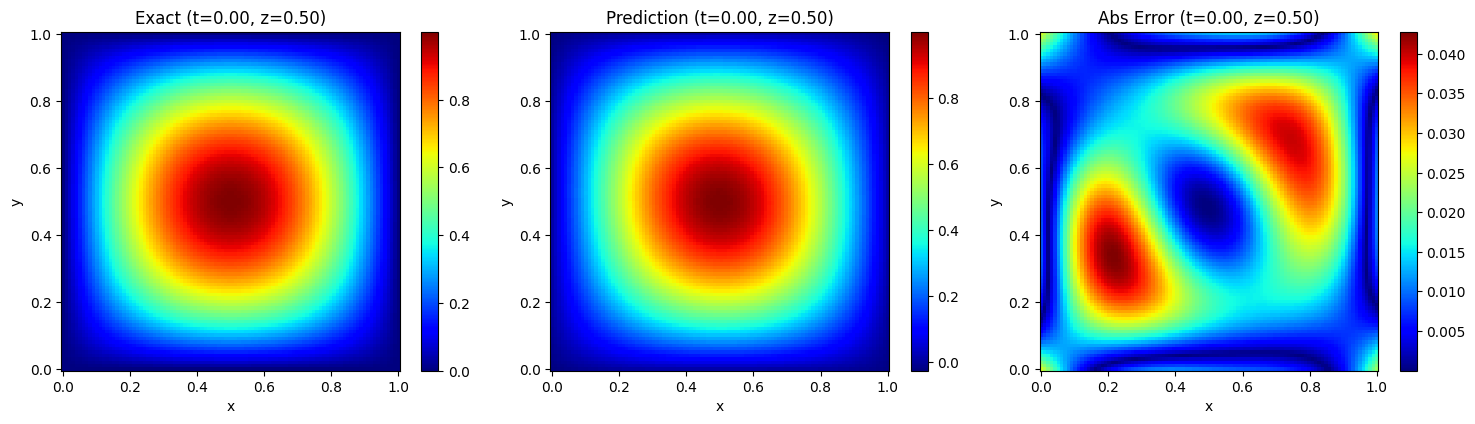

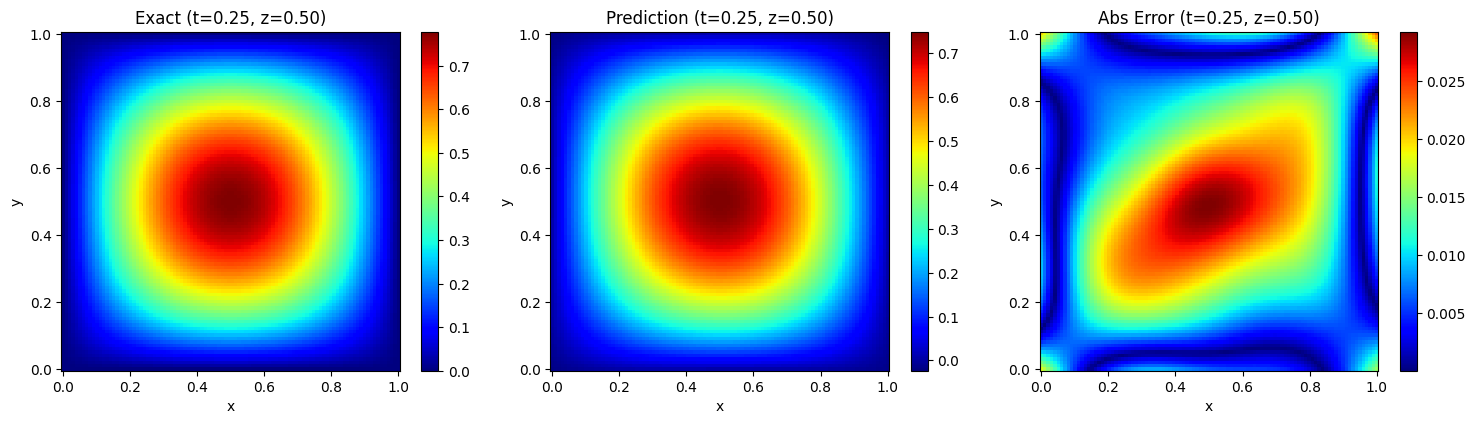

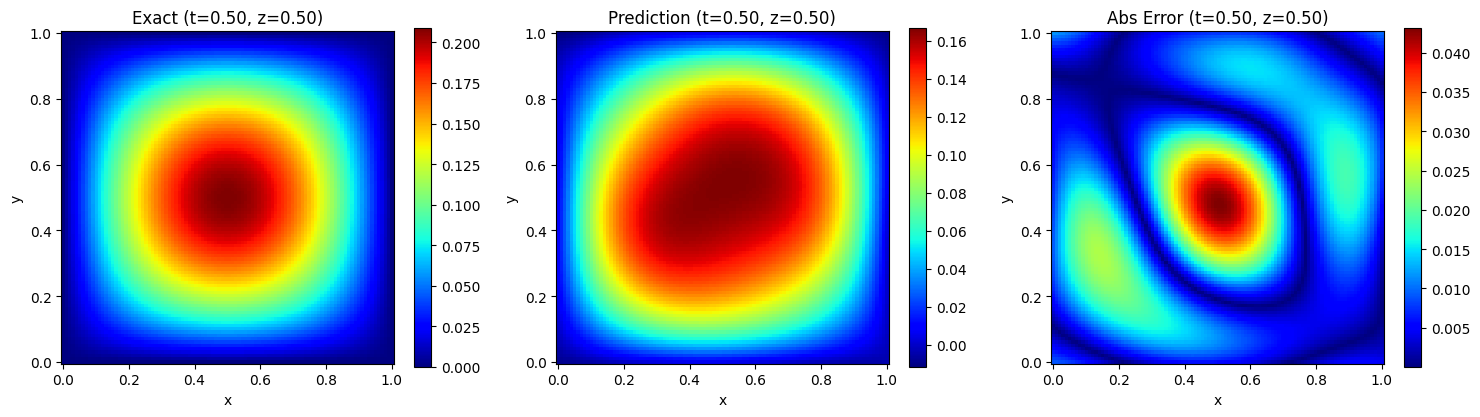


Visualizing Adaptive Sampling Points Distribution...
Using final adaptive sampling points from training...


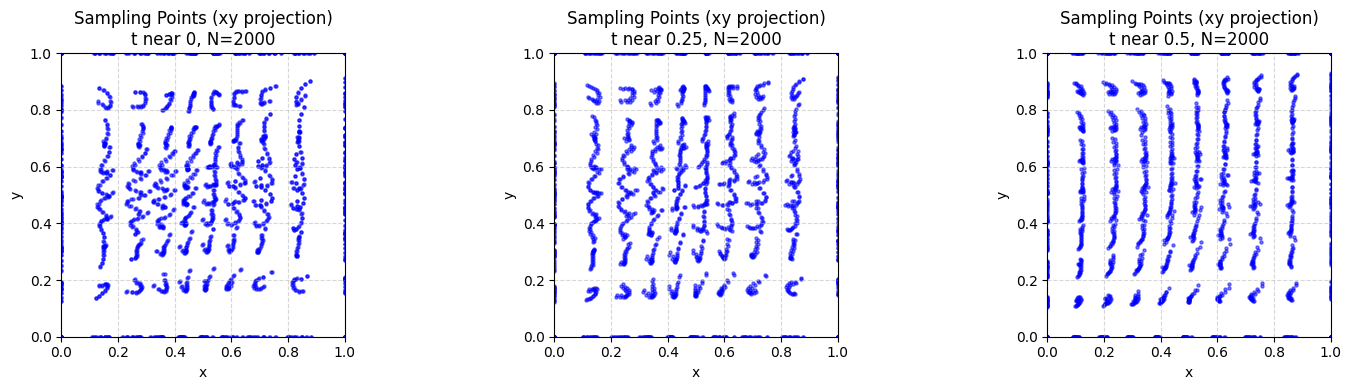


Generating 3D comparison plots...


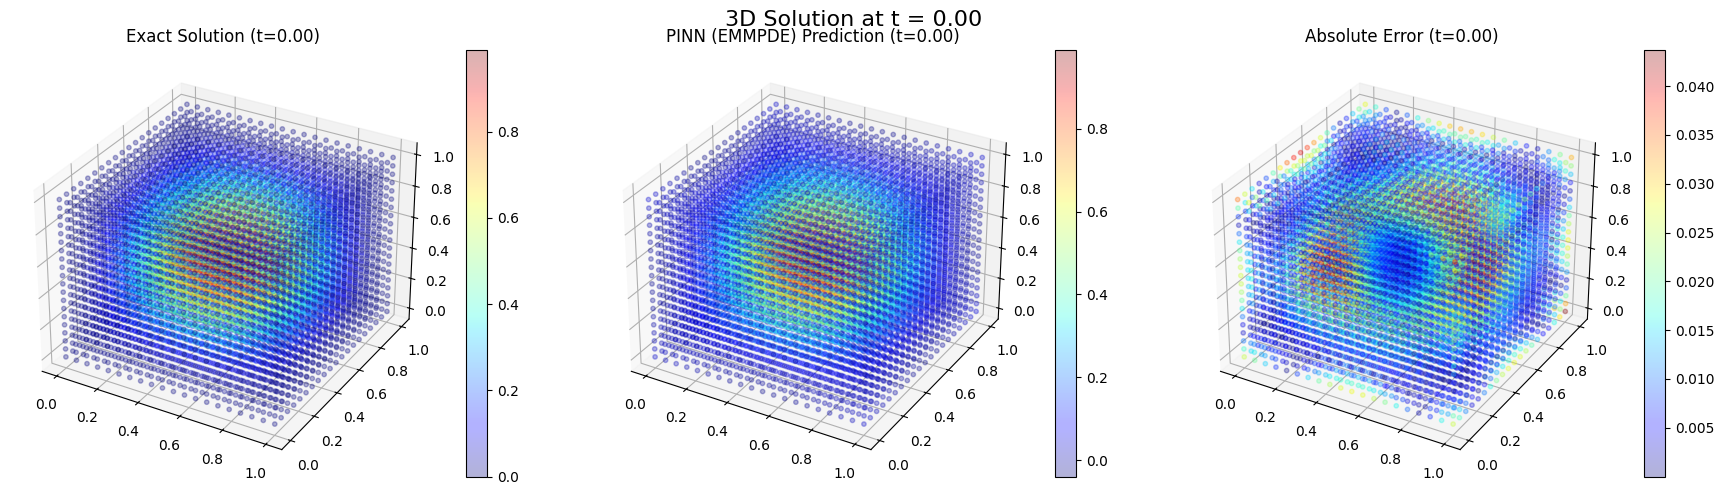

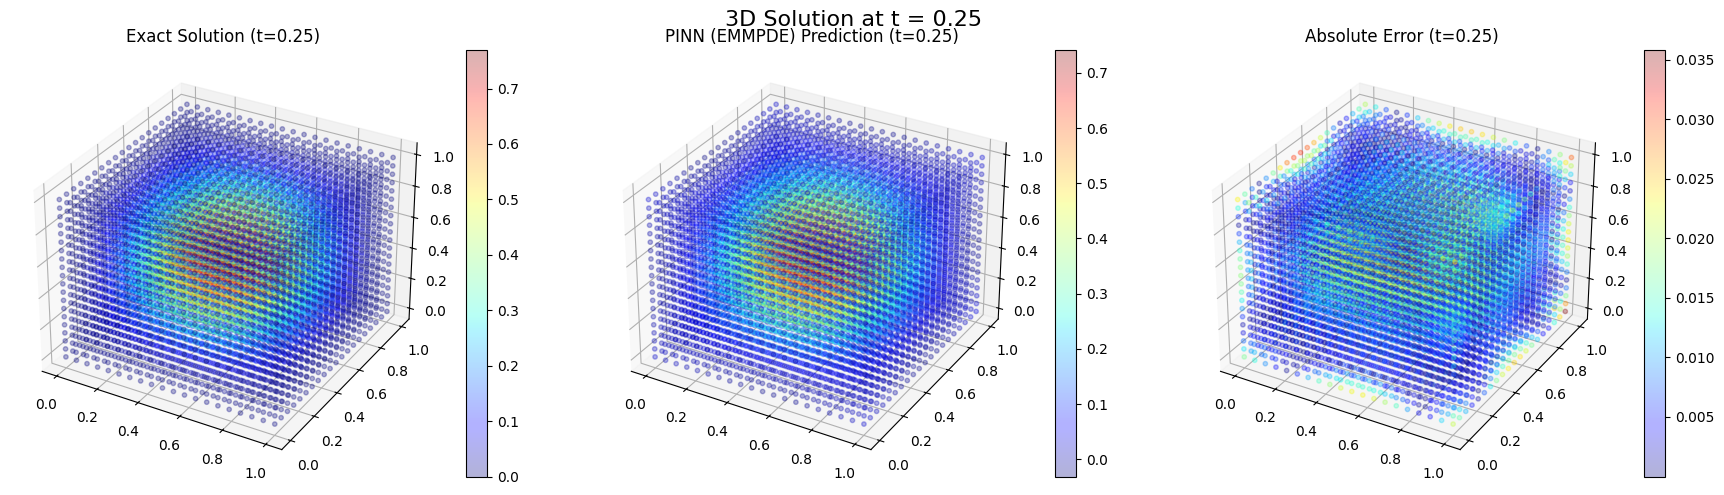

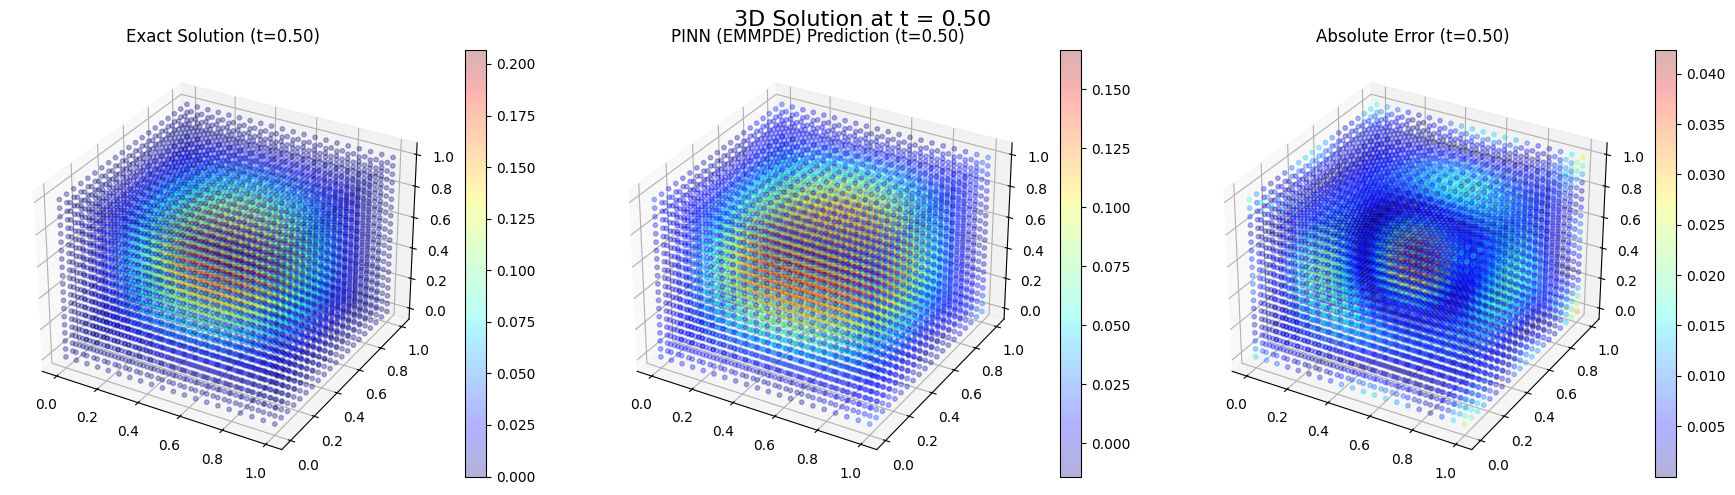

In [4]:
##%%
################################################################################
# Evaluation (Global L2 Error)
################################################################################
trained_model.eval()

print("Computing Global Relative L2 Error...")

grid_res = 20  # 20^4 points
t_vals = np.linspace(0, T, grid_res)
x_vals = np.linspace(0, Lx, grid_res)
y_vals = np.linspace(0, Ly, grid_res)
z_vals = np.linspace(0, Lz, grid_res)

T_mesh, X_mesh, Y_mesh, Z_mesh = torch.meshgrid(
    torch.tensor(t_vals, dtype=torch.float32),
    torch.tensor(x_vals, dtype=torch.float32),
    torch.tensor(y_vals, dtype=torch.float32),
    torch.tensor(z_vals, dtype=torch.float32),
    indexing='ij'
)

inputs = torch.cat([
    T_mesh.reshape(-1, 1),
    X_mesh.reshape(-1, 1),
    Y_mesh.reshape(-1, 1),
    Z_mesh.reshape(-1, 1)
], dim=1).to(device)

with torch.no_grad():
    u_pred = trained_model(inputs)[:, 0:1].cpu().numpy()

u_exact = exact_solution_u(
    X_mesh.numpy().reshape(-1, 1),
    Y_mesh.numpy().reshape(-1, 1),
    Z_mesh.numpy().reshape(-1, 1),
    T_mesh.numpy().reshape(-1, 1),
    c
)

error = u_pred - u_exact
l2_norm_error = np.sqrt(np.mean(error**2))
l2_norm_exact = np.sqrt(np.mean(u_exact**2))
rel_l2_error = l2_norm_error / (l2_norm_exact + 1e-12)

print(f"Global Relative L2 Error: {rel_l2_error:.5e}")
##%%
################################################################################
# 2D Slices Visualization (z = Lz/2)
################################################################################
print('\nGenerating 2D slice comparisons (z = Lz/2)...')

# Define time points and fixed z
times_2d = [0.0, T/2.0, T]
z_fixed = Lz / 2.0
grid_res_2d = 100

x_2d = np.linspace(0, Lx, grid_res_2d)
y_2d = np.linspace(0, Ly, grid_res_2d)
X_2d, Y_2d = np.meshgrid(x_2d, y_2d, indexing='ij')

for t_val in times_2d:
    # Prepare 2D grid inputs with fixed z and t
    X_flat = X_2d.reshape(-1, 1)
    Y_flat = Y_2d.reshape(-1, 1)

    t_tensor = torch.full((X_flat.shape[0], 1), t_val, dtype=torch.float32, device=device)
    x_tensor = torch.tensor(X_flat, dtype=torch.float32, device=device)
    y_tensor = torch.tensor(Y_flat, dtype=torch.float32, device=device)
    z_tensor = torch.full((X_flat.shape[0], 1), z_fixed, dtype=torch.float32, device=device)

    with torch.no_grad():
        inputs = torch.cat((t_tensor, x_tensor, y_tensor, z_tensor), dim=1)
        uv_pred = trained_model(inputs).cpu().numpy()
        u_pred = uv_pred[:, 0].reshape(X_2d.shape)

    u_exact = exact_solution_u(X_2d, Y_2d, z_fixed, t_val, c)
    abs_error = np.abs(u_pred - u_exact)

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 1. Exact
    im1 = axes[0].pcolormesh(X_2d, Y_2d, u_exact, cmap='jet', shading='auto')
    axes[0].set_title(f'Exact (t={t_val:.2f}, z={z_fixed:.2f})')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].set_aspect('equal')
    plt.colorbar(im1, ax=axes[0])

    # 2. Predicted
    im2 = axes[1].pcolormesh(X_2d, Y_2d, u_pred, cmap='jet', shading='auto')
    axes[1].set_title(f'Prediction (t={t_val:.2f}, z={z_fixed:.2f})')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    axes[1].set_aspect('equal')
    plt.colorbar(im2, ax=axes[1])

    # 3. Error
    im3 = axes[2].pcolormesh(X_2d, Y_2d, abs_error, cmap='jet', shading='auto')
    axes[2].set_title(f'Abs Error (t={t_val:.2f}, z={z_fixed:.2f})')
    axes[2].set_xlabel('x')
    axes[2].set_ylabel('y')
    axes[2].set_aspect('equal')
    plt.colorbar(im3, ax=axes[2])

    plt.tight_layout()
    plt.show()

################################################################################
# Adaptive Sampling Points Distribution (Projected to xy-plane)
################################################################################
print('\nVisualizing Adaptive Sampling Points Distribution...')

# Use final_sampling_points that was returned from training
print("Using final adaptive sampling points from training...")

t_samp = final_sampling_points[:, 0]
x_samp = final_sampling_points[:, 1]
y_samp = final_sampling_points[:, 2]
z_samp = final_sampling_points[:, 3]

# Plot projections at different time windows
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
time_windows = [(0.0, 0.1), (T/2 - 0.05, T/2 + 0.05), (T - 0.1, T)]
labels = [f"t near 0", f"t near {T/2}", f"t near {T}"]

for idx, (t_start, t_end) in enumerate(time_windows):
    # Select points in time window
    mask = (t_samp >= t_start) & (t_samp <= t_end)
    x_sel = x_samp[mask]
    y_sel = y_samp[mask]

    if len(x_sel) > 0:
        axes[idx].scatter(x_sel, y_sel, s=5, alpha=0.5, c='blue')
        axes[idx].set_title(f'Sampling Points (xy projection)\n{labels[idx]}, N={len(x_sel)}')
    else:
        axes[idx].text(0.5, 0.5, "No points in window", ha='center')
        axes[idx].set_title(f'{labels[idx]}')

    axes[idx].set_xlim(0, Lx)
    axes[idx].set_ylim(0, Ly)
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('y')
    axes[idx].set_aspect('equal')
    axes[idx].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
##%%
################################################################################
# 3D Visualization
################################################################################
print('\nGenerating 3D comparison plots...')

times_3d = [0.0, T/2.0, T]
grid_res_3d = 20
model = trained_model

x_3d = np.linspace(0, Lx, grid_res_3d)
y_3d = np.linspace(0, Ly, grid_res_3d)
z_3d = np.linspace(0, Lz, grid_res_3d)
X_3d, Y_3d, Z_3d = np.meshgrid(x_3d, y_3d, z_3d, indexing='ij')

for t_val in times_3d:
    t_val = float(t_val)

    X_flat = X_3d.reshape(-1, 1)
    Y_flat = Y_3d.reshape(-1, 1)
    Z_flat = Z_3d.reshape(-1, 1)
    T_flat = np.full_like(X_flat, t_val)

    t_tensor = torch.tensor(T_flat, dtype=torch.float32, device=device)
    x_tensor = torch.tensor(X_flat, dtype=torch.float32, device=device)
    y_tensor = torch.tensor(Y_flat, dtype=torch.float32, device=device)
    z_tensor = torch.tensor(Z_flat, dtype=torch.float32, device=device)

    with torch.no_grad():
        inputs = torch.cat((t_tensor, x_tensor, y_tensor, z_tensor), dim=1)
        uv_pred = model(inputs).cpu().numpy()
        u_pred = uv_pred[:, 0].reshape(X_3d.shape)

    u_exact = exact_solution_u(X_3d, Y_3d, Z_3d, t_val, c)
    abs_error = np.abs(u_pred - u_exact)

    fig = plt.figure(figsize=(18, 5))

    # 1. Exact Solution
    ax1 = fig.add_subplot(131, projection='3d')
    p1 = ax1.scatter(X_3d, Y_3d, Z_3d, c=u_exact, cmap='jet', alpha=0.3, s=10)
    ax1.set_title(f'Exact Solution (t={t_val:.2f})')
    plt.colorbar(p1, ax=ax1)

    # 2. Predicted Solution
    ax2 = fig.add_subplot(132, projection='3d')
    p2 = ax2.scatter(X_3d, Y_3d, Z_3d, c=u_pred, cmap='jet', alpha=0.3, s=10)
    ax2.set_title(f'PINN (EMMPDE) Prediction (t={t_val:.2f})')
    plt.colorbar(p2, ax=ax2)

    # 3. Absolute Error
    ax3 = fig.add_subplot(133, projection='3d')
    p3 = ax3.scatter(X_3d, Y_3d, Z_3d, c=abs_error, cmap='jet', alpha=0.3, s=10)
    ax3.set_title(f'Absolute Error (t={t_val:.2f})')
    plt.colorbar(p3, ax=ax3)

    plt.suptitle(f'3D Solution at t = {t_val:.2f}', fontsize=16)
    plt.tight_layout()
    plt.show()

In [5]:
###### compute energy (EMMPDE) #######
from scipy import integrate

def compute_energy_at_time_pinn(model, t_value, x1_range=(0, 1), x2_range=(0, 1), x3_range=(0, 1), num_points=100):
    """
    计算模型在特定时刻t的能量
    使用更密集的网格点以提高积分精度
    """
    # 创建空间网格
    x1_grid = np.linspace(x1_range[0], x1_range[1], num_points)
    x2_grid = np.linspace(x2_range[0], x2_range[1], num_points)
    x3_grid = np.linspace(x3_range[0], x3_range[1], num_points)
    X1, X2, X3 = np.meshgrid(x1_grid, x2_grid, x3_grid, indexing='ij')

    # 创建时空点 (t, x1, x2, x3)
    t_grid = t_value * np.ones_like(X1)
    points = np.stack([t_grid.flatten(), X1.flatten(), X2.flatten(), X3.flatten()], axis=1)
    
    # 转换为Tensor并移动到设备
    points_tensor = torch.from_numpy(points).float().to(device)

    # 计算 u 及其导数
    points_tensor.requires_grad_(True)
    model.eval()

    uv = model(points_tensor)
    u = uv[:, [0]]  # displacement u
    v = uv[:, [1]]  # velocity v = u_t

    # 计算一阶导数
    grad_u = torch.autograd.grad(u, points_tensor,
                                grad_outputs=torch.ones_like(u),
                                create_graph=True)[0]

    u_x1 = grad_u[:, 1]  # ∂u/∂x1
    u_x2 = grad_u[:, 2]  # ∂u/∂x2
    u_x3 = grad_u[:, 3]  # ∂u/∂x3

    # v就是u_t，所以u_t = v
    u_t = v.squeeze()  # velocity v = u_t

    # 计算能量密度：
    energy_density = 0.5 * (u_t**2 + c**2*(u_x1**2 + u_x2**2 + u_x3**2))

    # 重塑为网格形状
    energy_density = energy_density.reshape(num_points, num_points, num_points)

    # 数值积分计算总能量 (使用梯形法则)
    # Dx需要根据范围计算
    dx1 = (x1_range[1] - x1_range[0]) / (num_points - 1)
    dx2 = (x2_range[1] - x2_range[0]) / (num_points - 1)
    dx3 = (x3_range[1] - x3_range[0]) / (num_points - 1)


    total_energy = torch.trapz(
                   torch.trapz(
                       torch.trapz(energy_density, dx=dx3, dim=2),
                   dx=dx2, dim=1),
               dx=dx1, dim=0)

    return total_energy.cpu().detach().numpy().item()


def compute_energy_evolution(model, t_array):
    """
    计算能量随时间的演化，并计算相对误差
    """
    energies = []
    print("正在计算能量演化...")

    for i, t_val in enumerate(t_array):
        # 传递 global c? No, global variable c is used inside compute_energy_at_time_pinn
        energy = compute_energy_at_time_pinn(model, t_val, x1_range=(0, Lx), x2_range=(0, Ly), x3_range=(0, Lz))
        energies.append(energy)
        if i % 10 == 0:  # 每10个点打印一次进度
            print(f"进度: {i+1}/{len(t_array)}, t={t_val:.2f}, E={energy:.6f}")

    energies = np.array(energies)
    E0 = energies[0]  # 初始能量

    # 计算相对误差
    rel_errors = np.abs(energies - E0) / E0

    return energies, rel_errors, E0

def save_energy_data(filename, t_array, energies, rel_errors, E0, method_name="EMMPDE"):
    """
    保存能量数据到文件
    """
    data = {
        'time': t_array,
        'energies': energies,
        'relative_errors': rel_errors,
        'initial_energy': E0,
        'method': method_name
    }
    np.savez(filename, **data)
    print(f"能量数据已保存到 {filename}")

    # 同时保存为文本文件便于查看
    txt_filename = filename.replace('.npz', '.txt')
    with open(txt_filename, 'w') as f:
        f.write(f"# {method_name} Energy Evolution Data\n")
        f.write(f"# Initial Energy: {E0:.10e}\n")
        f.write("# Time\tEnergy\tRelative_Error\n")
        for t, E, rel_err in zip(t_array, energies, rel_errors):
            f.write(f"{t:.6f}\t{E:.10e}\t{rel_err:.10e}\n")
    print(f"能量数据已保存到 {txt_filename}")

# 执行能量计算
print("\n 开始计算EMMPDE能量及相对误差...")
t_energy = np.linspace(0, T, 50)
EMMPDE_energy, EMMPDE_rel_errors, EMMPDE_E0 = compute_energy_evolution(trained_model, t_energy)
save_energy_data('EMMPDE_energy_data.npz', t_energy, EMMPDE_energy, EMMPDE_rel_errors, EMMPDE_E0, 'EMMPDE')


 开始计算EMMPDE能量及相对误差...
正在计算能量演化...
进度: 1/50, t=0.00, E=0.422381
进度: 11/50, t=0.10, E=0.421663
进度: 21/50, t=0.20, E=0.421559
进度: 31/50, t=0.31, E=0.421423
进度: 41/50, t=0.41, E=0.421617
能量数据已保存到 EMMPDE_energy_data.npz
能量数据已保存到 EMMPDE_energy_data.txt
